# New Section

Train Shape: (614, 13)
Test Shape: (367, 12)

First 5 Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1     

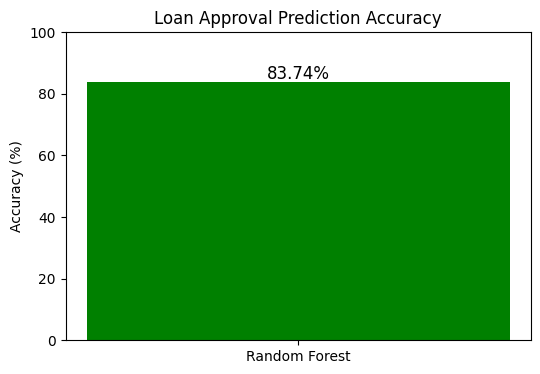

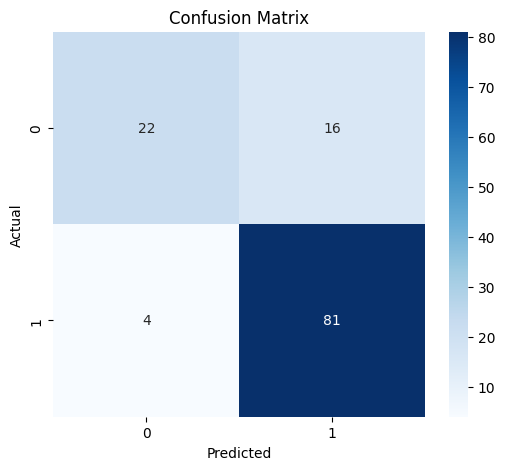


Training on Full Dataset...

Prediction file saved successfully!
    Loan_ID Loan_Status
0  LP001015           Y
1  LP001022           Y
2  LP001031           Y
3  LP001035           Y
4  LP001051           Y


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# ==========================
# LOAD DATASET
# ==========================

train_path = "train.csv"
test_path = "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

print("\nFirst 5 Rows:")
print(train_df.head())

# ==========================
# TARGET COLUMN
# ==========================

target_column = "Loan_Status"   # Change if needed

if target_column not in train_df.columns:
    raise ValueError(f"Target column '{target_column}' not found!")

# ==========================
# FEATURES & TARGET
# ==========================

X = train_df.drop(columns=[target_column])
y = train_df[target_column]

# Encode target labels (Y/N -> 1/0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ==========================
# HANDLE LOAN ID
# ==========================

test_ids = None

if "Loan_ID" in test_df.columns:
    test_ids = test_df["Loan_ID"]

if "Loan_ID" in X.columns:
    X = X.drop(columns=["Loan_ID"])

if "Loan_ID" in test_df.columns:
    test_features = test_df.drop(columns=["Loan_ID"])
else:
    test_features = test_df.copy()

# ==========================
# FEATURE ENGINEERING
# ==========================

if "ApplicantIncome" in X.columns and "CoapplicantIncome" in X.columns:
    X["TotalIncome"] = X["ApplicantIncome"] + X["CoapplicantIncome"]
    test_features["TotalIncome"] = (
        test_features["ApplicantIncome"] +
        test_features["CoapplicantIncome"]
    )

# ==========================
# NUMERIC & CATEGORICAL
# ==========================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

# ==========================
# PREPROCESSING PIPELINES
# ==========================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ==========================
# MODEL PIPELINE
# ==========================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         RandomForestClassifier(
             n_estimators=300,
             max_depth=10,
             random_state=42
         ))
    ]
)

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# TRAIN MODEL
# ==========================

print("\nTraining Model...")

model.fit(X_train, y_train)

# ==========================
# VALIDATION PREDICTIONS
# ==========================

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

# ==========================
# ACCURACY BAR CHART
# ==========================

plt.figure(figsize=(6, 4))

plt.bar(
    ["Random Forest"],
    [accuracy * 100],
    color="green"
)

plt.ylim(0, 100)

plt.title("Loan Approval Prediction Accuracy")
plt.ylabel("Accuracy (%)")

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy*100:.2f}%",
    ha="center",
    fontsize=12
)

plt.show()

# ==========================
# CONFUSION MATRIX
# ==========================

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================
# TRAIN ON FULL DATA
# ==========================

print("\nTraining on Full Dataset...")

model.fit(X, y)

# ==========================
# PREDICT TEST DATA
# ==========================

test_predictions = model.predict(test_features)

test_predictions_labels = (
    label_encoder.inverse_transform(
        test_predictions
    )
)

# ==========================
# SAVE OUTPUT
# ==========================

if test_ids is not None:
    submission = pd.DataFrame({
        "Loan_ID": test_ids,
        "Loan_Status": test_predictions_labels
    })
else:
    submission = pd.DataFrame({
        "Loan_Status": test_predictions_labels
    })

submission.to_csv(
    "loan_prediction_output.csv",
    index=False
)

print("\nPrediction file saved successfully!")
print(submission.head())